In [ ]:
#pip install pgmpy

In [46]:
import networkx as nx
import matplotlib.pyplot as plt
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD

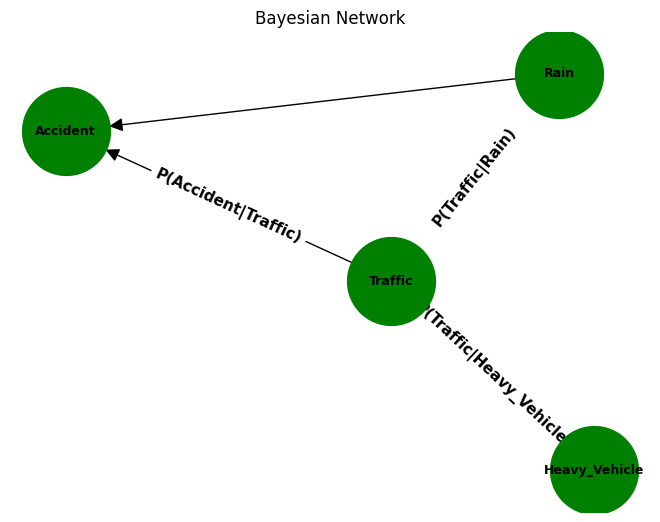

In [47]:
H = nx.DiGraph()
nodes = ["Rain","Accident", "Heavy_Vehicle", "Traffic"]
H.add_nodes_from(nodes)

edges=[("Rain","Accident"),("Heavy_Vehicle", "Traffic"),("Traffic","Accident")]
H.add_edges_from(edges)

pos=nx.spring_layout(H,seed=70)
nx.draw(H,pos,with_labels=True,node_size=4000,node_color="Green",font_size=9,arrowsize=20,font_weight="bold",font_color='k')
labels={
    ("Rain","Traffic"):"P(Traffic|Rain)",
    ("Heavy_Vehicle","Traffic"):"P(Traffic|Heavy_Vehicle)",
    ("Traffic","Accident"):"P(Accident|Traffic)"
}

nx.draw_networkx_edge_labels(H,pos,edge_labels = labels,font_size=11,font_weight="bold",font_color='k')
plt.title("Bayesian Network")
plt.show()

In [48]:
Network = DiscreteBayesianNetwork(edges)

In [49]:
cpd_Rain = TabularCPD(variable =  'Rain',variable_card = 2,values = [[0.2],[0.8]])

cpd_Accident = TabularCPD(variable = 'Accident',variable_card = 2, values= [[0.95],[0.05]])

cpd_Heavy_Vehicle = TabularCPD(variable = 'Heavy_Vehicle',variable_card = 2, values= [[0.25],[0.75]])

cpd_Traffic = TabularCPD(variable = 'Traffic',variable_card = 2, values=[[0, 0.25, 0.95 ,0.9625, 0.2, 0.4, 0.06, 0.07],
                                                                         [1, 0.75, 0.05, 0.0375, 0.8, 0.6, 0.94, 0.93 ]],
                          evidence = ['Rain','Accident','Heavy_Vehicle'],
                          evidence_card = [2,2,2])

Network.add_cpds(cpd_Rain,cpd_Accident,cpd_Heavy_Vehicle,cpd_Traffic)

print("The CPD of Rain is :\n", cpd_Rain)
print("The CPD of Accident is :\n", cpd_Accident)

print("The CPD of Heavy_Vehicle is :\n", cpd_Heavy_Vehicle)

print("The CPD of Traffic is :\n", cpd_Traffic)

P_Rain = cpd_Rain.values[1]
P_Accident = cpd_Accident.values[1]
P_Heavy_Vehicle = cpd_Heavy_Vehicle.values[1]

print("\n Example Extracted Probabilities:")
print("P(Rain) = ",P_Rain)
print("P(Accident) = ",P_Accident)
print("P(Heavy_Vehicle) = ",P_Heavy_Vehicle)

The CPD of Rain is :
 +---------+-----+
| Rain(0) | 0.2 |
+---------+-----+
| Rain(1) | 0.8 |
+---------+-----+
The CPD of Accident is :
 +-------------+------+
| Accident(0) | 0.95 |
+-------------+------+
| Accident(1) | 0.05 |
+-------------+------+
The CPD of Heavy_Vehicle is :
 +------------------+------+
| Heavy_Vehicle(0) | 0.25 |
+------------------+------+
| Heavy_Vehicle(1) | 0.75 |
+------------------+------+
The CPD of Traffic is :
 +---------------+------------------+-----+------------------+
| Rain          | Rain(0)          | ... | Rain(1)          |
+---------------+------------------+-----+------------------+
| Accident      | Accident(0)      | ... | Accident(1)      |
+---------------+------------------+-----+------------------+
| Heavy_Vehicle | Heavy_Vehicle(0) | ... | Heavy_Vehicle(1) |
+---------------+------------------+-----+------------------+
| Traffic(0)    | 0.0              | ... | 0.07             |
+---------------+------------------+-----+-------------

In [50]:
P_Rain = cpd_Rain.values[1]
P_Accident = cpd_Accident.values[0]
P_Heavy_Vehicle = cpd_Heavy_Vehicle.values[1]
P_Traffic_given_Rain_not_Accident_Heavy_Vehicle = cpd_Traffic.values[1,1,0,1]
P_Traffic = P_Rain*P_Accident*P_Heavy_Vehicle*P_Traffic_given_Rain_not_Accident_Heavy_Vehicle
print("P(Rain=T, Accident = F, Heavy_vechicle = T)=",P_Traffic)

P(Rain=T, Accident = F, Heavy_vechicle = T)= 0.342
